# Imports

In [6]:
!pip install seaborn

In [7]:
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns
import math
import time

# Function Definitions

## Rotation Matrices

In [8]:
def xRot(theta):
    # Rotation matrix for the x axis
    angle = math.radians(theta)
    mat = np.array([[1, 0, 0],
                   [0, math.cos(angle), math.sin(angle)],
                   [0, -math.sin(angle), math.cos(angle)]])
    return mat

In [9]:
def yRot(theta):
    # Rotation matrix for the y axis
    angle = math.radians(theta)
    mat = np.array([[math.cos(angle), 0, math.sin(angle)],
                   [0, 1, 0],
                   [-math.sin(angle), 0, math.cos(angle)]])
    return mat

In [10]:
def zRot(theta):
    # Rotation matrix for the z axis
    angle = math.radians(theta)
    mat = np.array([[math.cos(angle), math.sin(angle), 0],
                   [-math.sin(angle), math.cos(angle), 0],
                   [0, 0, 1]])
    return mat

## Body Functions

In [11]:
def bodyPos(pitch = 0, roll = 0, yaw = 0, Tx = 0, Ty = 0, Tz = 0):
    # Applies rotations in pitch, roll, and yaw and translations in x, y, and z tot he body.
    body_rot = np.matmul(zRot(yaw), yRot(roll))
    body_rot = np.matmul(body_rot, xRot(pitch));
    
    body_0 = np.matmul(inv(body_rot), np.array([[body_offset / 2, body_offset * math.sin(math.pi / 3), 0]]).T);
    body_1 = np.matmul(inv(body_rot), np.array([[body_offset, 0, 0]]).T);
    body_2 = np.matmul(inv(body_rot), np.array([[body_offset / 2, -body_offset * math.sin(math.pi / 3), 0]]).T);
    body_3 = np.matmul(inv(body_rot), np.array([[-body_offset / 2, -body_offset * math.sin(math.pi / 3), 0]]).T);
    body_4 = np.matmul(inv(body_rot), np.array([[-body_offset, 0, 0]]).T);
    body_5 = np.matmul(inv(body_rot), np.array([[-body_offset / 2, body_offset * math.sin(math.pi / 3), 0]]).T);
    
    body_model = np.concatenate((body_0.T, body_1.T, body_2.T, body_3.T, body_4.T, body_5.T, body_0.T), axis = 0)
    translation = [[Tx, Ty, Tz],
    [Tx, Ty, Tz],
    [Tx, Ty, Tz],
    [Tx, Ty, Tz],
    [Tx, Ty, Tz],
    [Tx, Ty, Tz],
    [Tx, Ty, Tz]]
    
    body_model = body_model + translation
    
    return body_model

## Leg Functions

In [12]:
def legPos(coax_angle, femur_angle, tibia_angle, body_model, leg_num):
    # finds the positions for the coax, femur, and tibia leg segments and adds them to the body model
    coax_rot = zRot(coax_angle)
    femur_rot = np.matmul(yRot(femur_angle), coax_rot)
    tibia_rot = np.matmul(yRot(tibia_angle), femur_rot)
    
    leg_coax = np.matmul(inv(coax_rot), np.array([[coax, 0, 0]]).T) + np.array([body_model[leg_num, :]]).T
    leg_femur = np.matmul(inv(femur_rot), np.array([[femur, 0, 0]]).T) + leg_coax
    leg_tibia = np.matmul(inv(tibia_rot), np.array([[0, 0, -tibia]]).T) + leg_femur
                       
    leg_positions = np.concatenate((np.array([body_model[leg_num, :]]), leg_coax.T, leg_femur.T, leg_tibia.T), axis = 0)
    return leg_positions

In [ ]:
def legAngle(x, y, z):
    # finds the angles for the coax, femur, and tibia leg segments
    coax_angle = math.degrees(math.atan2(y, x));
    coax_rot = zRot(-coax_angle)
    leg_rotated = np.matmul(inv(coax_rot), np.array([[x, y, z]]).T).flatten()
    femur_angle = math.degrees(math.acos((tibia ** 2 - femur ** 2 - leg_rotated[2] ** 2 - (leg_rotated[0] - coax) ** 2) / (-2 * femur * (math.sqrt(leg_rotated[2] ** 2 + (leg_rotated[0] - coax) ** 2))))) - math.degrees(math.atan2(-leg_rotated[2], (leg_rotated[0] - coax)));
    tibia_angle = math.degrees(math.acos((leg_rotated[2] ** 2 + (leg_rotated[0] - coax) ** 2 - femur ** 2 - tibia ** 2) / (-2 * femur * tibia))) - 90;
    
    if abs(coax_angle) <= 1e-10:
        coax_angle = 0;
        
    if abs(femur_angle) <= 1e-10:
        femur_angle = 0;
    
    if abs(tibia_angle) <= 1e-10:
        tibia_angle = 0;
    
    return [coax_angle, femur_angle, tibia_angle]

### Create the starting angles of the legs on the hexapod based 

In [14]:
def startLegPos(body_model, start_radius = 150, start_height = 20):
    start_leg_pos = np.array([[start_radius * math.cos(math.pi / 3), start_radius * math.sin(math.pi / 3), - start_height],
    [start_radius, 0, - start_height],
    [start_radius * math.cos(- math.pi / 3), start_radius * math.sin(- math.pi / 3), - start_height],
    [start_radius * math.cos(- 2 * math.pi / 3) , start_radius * math.sin(- 2 * math.pi / 3), - start_height],
    [- start_radius, 0, - start_height],
    [start_radius * math.cos(2 * math.pi / 3), start_radius * math.sin(2 * math.pi / 3), - start_height]])
    start_leg =  recalculateLegAngles(start_leg_pos, body_model)
    return start_leg

### Get the current feet positions

In [15]:
def getFeetPos(leg_model):
    feet_positions = np.empty([6, 3])
    for i in range(6):
        feet_positions[i, :] = leg_model[3, :, i]
    return feet_positions

### General Foot Position to Leg Angle Function

In [16]:
def recalculateLegAngles(feet_positions, body_model):
    leg_angles = np.empty([6, 3])
    for i in range(6):
        leg_angles[i, :] = legAngle(feet_positions[i, 0] - body_model[i, 0], feet_positions[i, 1] - body_model[i, 1], feet_positions[i, 2] - body_model[i, 2])
    return leg_angles

### Apply Leg Angles to Model

In [17]:
def legModel(leg_angles, body_model):
    leg_model = np.empty([4, 3, 6])
    for i in range(6):
        leg_model[:, :, i] = legPos(leg_angles[i][0], leg_angles[i][1], leg_angles[i][2], body_model, i) #coax angle, femur angle, tibia angle, model of the hexapod body, leg number
    return leg_model

## Walking Functions

### Step Calculations

In [18]:
def stepForward(step_angle = 90, distance = 30, step_height = 15, right_foot = True):
    z_resolution = 1 # the forward distance of each sub step.
    x_resolution = z_resolution * math.cos(math.radians(step_angle))
    y_resolution = z_resolution * math.sin(math.radians(step_angle))

    z = np.array([-(i ** 2) / 4 + ((step_height) ** 2) / 4 for i in np.arange (- step_height, step_height + z_resolution, z_resolution)])
    x = np.linspace(0, distance * math.cos(math.radians(step_angle)), z.size)
    y = np.linspace(0, distance * math.sin(math.radians(step_angle)), z.size)
    lead_foot = np.dstack((x, y, z)).reshape(z.size, 1, 3)
    dragging_foot = np.dstack((- x, - y, np.zeros(z.size))).reshape(z.size, 1, 3)
    
    #define legs 0, 2, and 4 as the right legs and legs 1, 3, 5 as the left legs
    if right_foot: #right foot
        feet = np.concatenate((lead_foot, dragging_foot, lead_foot, dragging_foot, lead_foot, dragging_foot), axis = 1)
    else:
        feet = np.concatenate((dragging_foot, lead_foot, dragging_foot, lead_foot, dragging_foot, lead_foot), axis = 1)
        
    return feet

In [19]:
def stepTurnFoot(foot_x, foot_y, foot_z, step_angle = 15, step_height = 15, right_foot = True):
    z_resolution = 1 # the forward distance of each sub step.
    radius = math.sqrt(foot_x ** 2 + foot_y ** 2)
    foot_angle = math.degrees(math.atan2(foot_y, foot_x))

    z = np.array([-(i ** 2) / 4 + ((step_height) ** 2) / 4 + foot_z for i in np.arange (- step_height, step_height + z_resolution, z_resolution)])
    x = np.empty(z.size)
    y = np.empty(z.size)
    angles = np.linspace(foot_angle, foot_angle + step_angle, z.size)
    for i, angle in enumerate(angles):
        x[i] = radius * math.cos(math.radians(angle))
        y[i] = radius * math.sin(math.radians(angle))
    
    #define legs 0, 2, and 4 as the right legs and legs 1, 3, 5 as the left legs
    if right_foot: #right foot
        angles = np.linspace(foot_angle, foot_angle + step_angle, z.size)
    else:
        angles = np.linspace(foot_angle, foot_angle - step_angle, z.size)
        z = np.zeros(z.size) + foot_z
    
    for i, angle in enumerate(angles):
        x[i] = radius * math.cos(math.radians(angle))
        y[i] = radius * math.sin(math.radians(angle))

    return np.dstack((x, y, z)).reshape(z.size, 1, 3)

In [20]:
def stepTurn(feet_pos, step_angle = 15, step_height = 15, right_foot = True):
    for i in range(6):
        footstep = stepTurnFoot(foot_x = feet_pos[i, 0], foot_y = feet_pos[i, 1], foot_z = feet_pos[i, 2], step_angle = step_angle, step_height = step_height, right_foot = right_foot)
        right_foot = not right_foot
        if i == 0:
            previous_foot = footstep
        else:
            previous_foot = np.concatenate((previous_foot, footstep), axis = 1)
            
    return previous_foot

### Walk Cycle

In [21]:
def walk(body_model, leg_model, fig, distance = 30, angle = 90):
    max_step_size = 30 #Maximum step distance
    if distance <= 0: #raise an error if the robot is not commanded to move a positive distance
        raise ValueError("distance must be a positive distance")
    else: #find the number of steps to take
        steps = int(distance / max_step_size)
        if distance % max_step_size > 0:
            steps += 1
    
    right_foot = True; #If the right foot is moving forward
    remaining_distance = distance #Sets the remaining distance to move forward as the full distane to move
    for i in range(steps): #iterate over the number of steps to take
        if remaining_distance <= max_step_size: #if the remaining distance to move is less than the max step size, then move the robot remaining distance
            if steps == 1: #if this is the only step then the feet only needs to move forward the remaining distance
                temp_walk_positions = stepForward(step_angle = angle, distance = remaining_distance, right_foot = right_foot)
            else: #if this is not the first step the robot needs to move forward the max step size first to bring the robot to a neutral position before moving the rest of the distance.
                temp_walk_positions = stepForward(step_angle = angle, distance = remaining_distance + max_step_size, right_foot = right_foot)
                
            try: #try to get the current feet positions from the last stepped position
                feet_positions = walk_positions[-1, :, :]
            except: #if there was not a step yet get the feet positions from the leg model
                feet_positions = getFeetPos(leg_model)
            for j in range(temp_walk_positions.shape[0]): #add all of the feet positions to the walk
                temp_walk_positions[j, :, :] = temp_walk_positions[j, :, :] + feet_positions
            try: # try to add the next step to the walk
                walk_positions = np.concatenate((walk_positions, temp_walk_positions), axis = 0)
            except: #if this is the first step, create the walk array with the first step
                walk_positions = temp_walk_positions
            right_foot = not right_foot #switch which foot steps forward
            break
        
        elif i == 0: #if this is the first of more than one step, move forward the max distance
            walk_positions = stepForward(step_angle = angle, distance = max_step_size, right_foot = right_foot)
            feet_positions = getFeetPos(leg_model)
            for j in range(walk_positions.shape[0]):
                walk_positions[j, :, :] = walk_positions[j, :, :] + feet_positions
            remaining_distance -= max_step_size #reduce the remaining distance by the max step size
            right_foot = not right_foot
            
        else: #if this is not the first step and the next step is more than the max distance, move the legs forward by twice the max distance to reset and then move forward the max distance
            temp_walk_positions = stepForward(step_angle = angle, distance = max_step_size * 2, right_foot = right_foot)
            
            try:
                feet_positions = walk_positions[-1, :, :]
            except:
                feet_positions = getFeetPos(leg_model)
            for j in range(temp_walk_positions.shape[0]):
                temp_walk_positions[j, :, :] = temp_walk_positions[j, :, :] + feet_positions
            walk_positions = np.concatenate((walk_positions, temp_walk_positions), axis = 0)
            remaining_distance -= max_step_size
            right_foot = not right_foot
            
    temp_walk_positions = stepForward(step_angle = angle, distance = remaining_distance, right_foot = right_foot) #reset the position of the robot by moving the last step distance
    
    feet_positions = walk_positions[-1, :, :]
    for j in range(temp_walk_positions.shape[0]):
        temp_walk_positions[j, :, :] = temp_walk_positions[j, :, :] + feet_positions
    walk_positions = np.concatenate((walk_positions, temp_walk_positions), axis = 0)
    #create a video of the walk cycle
    Writer = animation.writers['ffmpeg']
    writer = Writer(fps=20, metadata=dict(artist='Nabeel'), bitrate=1800)
    elev = 15
    azim  = -15
    ani = animation.FuncAnimation(fig, animate, frames=walk_positions.shape[0], repeat=True, fargs = (walk_positions, body_model, leg_model, elev, azim, fig))
    ani.save('../Docs/Media/Hexapod_Walk.mp4', writer=writer)
    return walk_positions

### Turn Cycle

In [22]:
def turn(body_model, leg_model, fig, turn_angle = 60):
    max_turn_angle = 15 #sets the maximum angle to turn by.
    if turn_angle == 0: #Raise an error is the robot is not commanded to move a non zero angle
        raise ValueError("turn angle must be a number larger than 0.")
    else: #find the number of steps to take
        steps = int(abs(turn_angle / max_turn_angle))
        if abs(turn_angle % max_turn_angle) > 0:
            steps += 1
    
    right_foot = True; #If the right foot is moving forward
    remaining_turn_distance = turn_angle #Sets the remaining turn distance to the full turn
    for i in range(steps): #iterate over the number of steps to take
        if abs(remaining_turn_distance) <= max_turn_angle: #if the remaining turn distance to move is less than the max turn angle, then turn the robot the remaining angle
            try: #try to get the current feet positions from the last stepped position
                feet_positions = turn_positions[-1, :, :]
            except: #if there was not a step yet get the feet positions from the leg model
                feet_positions = getFeetPos(leg_model)
                
            if steps == 1: #if this is the only step then the feet only need to turn the robot the remaining turn distance
                temp_turn_positions = stepTurn(feet_positions, step_angle = remaining_turn_distance, right_foot = right_foot)
            else: #if this is not the first step the robot needs to move forward the max turn size first to bring the robot to a neutral position before moving the rest of the distance.
                temp_turn_positions = stepTurn(feet_positions, step_angle = np.sign(remaining_turn_distance) * (abs(remaining_turn_distance) + max_turn_angle), right_foot = right_foot)

            try: # try to add the next step to the walk
                turn_positions = np.concatenate((turn_positions, temp_turn_positions), axis = 0)
            except: #if this is the first step, create the walk array with the first step
                turn_positions = temp_turn_positions
            right_foot = not right_foot #switch which foot steps forward
            break
        
        elif i == 0: #if this is the first of more than one step, turn the max angle
            feet_positions = getFeetPos(leg_model)
            turn_positions = stepTurn(feet_positions, step_angle = np.sign(remaining_turn_distance) * max_turn_angle, right_foot = right_foot)
            remaining_turn_distance -= np.sign(remaining_turn_distance) * max_turn_angle #reduce the remaining distance by the max step size
            right_foot = not right_foot
            
        else: #if this is not the first step and the next step is more than the max angle, move the legs forward by twice the max angle to reset and then turn the max distance
            try:
                feet_positions = turn_positions[-1, :, :]
            except:
                feet_positions = getFeetPos(leg_model)
                
            temp_turn_positions = stepTurn(feet_positions, step_angle = np.sign(remaining_turn_distance) * max_turn_angle * 2, right_foot = right_foot)
            
            turn_positions = np.concatenate((turn_positions, temp_turn_positions), axis = 0)
            remaining_turn_distance -= np.sign(remaining_turn_distance) * max_turn_angle
            right_foot = not right_foot
    
    feet_positions = turn_positions[-1, :, :]
    temp_turn_positions = stepTurn(feet_positions, step_angle = remaining_turn_distance, right_foot = right_foot) #reset the position of the robot by moving the last step distance

    turn_positions = np.concatenate((turn_positions, temp_turn_positions), axis = 0)
    #create a video of the turn cycle
    Writer = animation.writers['ffmpeg']
    writer = Writer(fps=20, metadata=dict(artist='Nabeel'), bitrate=1800)
    elev = 60
    azim  = -15
    ani = animation.FuncAnimation(fig, animate, frames=turn_positions.shape[0], repeat=True, fargs = (turn_positions, body_model, leg_model, elev, azim, fig))
    if turn_angle > 0:
        ani.save('../Docs/Media/Hexapod_Turn_Left.mp4', writer=writer)
    else:
        ani.save('../Docs/Media/Hexapod_Turn_Right.mp4', writer=writer)
    return turn_positions

## Plot Model

In [23]:
def showModel(body_model, leg_model, fig, floor = -20, elev = 15, azim = -15):
    fig.clf()
    ax = plt.axes(projection ='3d')
    # plotting
    ax.plot3D(body_model[:, 0], body_model[:, 1], body_model[:, 2], 'green');
    for i in range(6):
        #"right" legs are blue and "left" legs are red
        if i % 2 == 0:
            ax.plot3D(leg_model[:, 0, i], leg_model[:, 1, i], leg_model[:, 2, i], 'blue');
        else:
            ax.plot3D(leg_model[:, 0, i], leg_model[:, 1, i], leg_model[:, 2, i], 'red');
    ax.set_xlim(-200, 200);
    ax.set_ylim(-200, 200);
    ax.set_zlim(floor, 100);
    ax.view_init(elev, azim)
    
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
    fig.canvas.draw()
    fig.canvas.flush_events()

In [24]:
def animate(i, positions, body_model, leg_model, elev, azim, fig):
    leg_model = legModel(recalculateLegAngles(positions[i, :, :], body_model), body_model)
    showModel(body_model, leg_model, fig = fig, elev = elev, azim = azim)

In [25]:
def animateBodyTranslate(i, elev, azim, fig):
    angles = list(range(0, 360, 5))
    if i < 72:
        y = math.sin(math.radians(angles[i])) * 40
        x = math.cos(math.radians(angles[i])) * 40
        body_model = bodyPos(0, 0, 0, x, y, 0);
    elif i < 80:
        x_pos = list(range(40, 0, -5))
        body_model = bodyPos(0, 0, 0, x_pos[i - 72], 0, 0);
    elif i < 160:
        z_pos = list(range(0, 21)) + list(range(19, -21, -1)) + list(range(-19, 0))
        body_model = bodyPos(0, 0, 0, 0, 0, z_pos[i - 80]);
    elif i < 162:
        roll = (i - 159) * 5
        body_model = bodyPos(0, roll, 0, 0, 0, 0);
    elif i < 234:
        z_pitch = math.sin(math.radians(angles[i - 162])) * 0.25
        z_roll = math.cos(math.radians(angles[i - 162]))* 0.25
        roll = math.degrees(math.atan2(z_roll,1))
        pitch = math.degrees(math.atan2(z_pitch,1))
        body_model = bodyPos(pitch, roll, 0, 0, 0, 0);
    elif i < 236:
        roll = 15 - (i - 234) * 5
        body_model = bodyPos(0, roll, 0, 0, 0, 0);
    elif i < 353:
        yaw_angle = list(range(0, 31)) + list(range(29, -31, -1)) + list(range(-29, 0))
        body_model = bodyPos(0, 0, yaw_angle[i - 236], 0, 0, 0);
    elif i < 362:
        x_pos = list(range(0, 40, 5))
        body_model = bodyPos(0, 0, 0, x_pos[i - 353], 0, 0);
    
    start_leg = startLegPos(body_model)
    leg_model = legModel(start_leg, body_model)    
    showModel(body_model, leg_model, fig = fig, elev = elev, azim = azim)

# Hexapod Measurments

In [26]:
# hexapod measurments
body_offset = 85 #mm
coax = 26.34 #mm
femur = 76.2 #mm
tibia = 88.32 #mm

# Body Starting Position

In [27]:
body_model = bodyPos(0, 0, 0, 0, 0, 0);

In [30]:
print(type(leg_rotated[0]))
print(leg_rotated.shape)

NameError: name 'leg_rotated' is not defined

# Leg Starting Positions

In [29]:
start_leg = startLegPos(body_model)
leg_model = legModel(start_leg, body_model)

TypeError: only 0-dimensional arrays can be converted to Python scalars

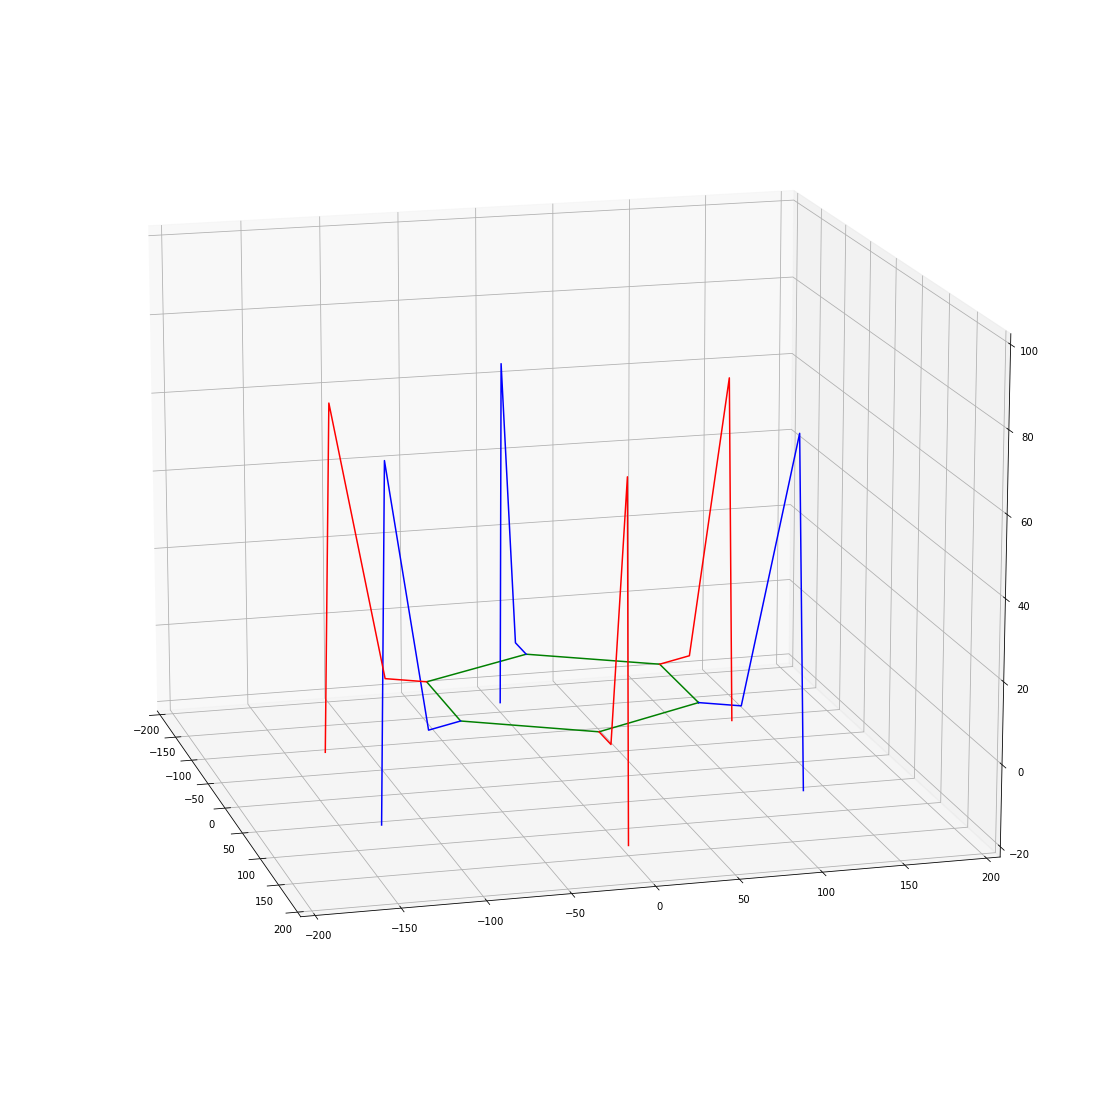

In [ ]:
%matplotlib inline
plt.close()
fig = plt.figure(figsize=[15, 15])
showModel(body_model, leg_model, fig = fig)

In [ ]:
%matplotlib qt
plt.close()
fig = plt.figure(figsize=[15, 15])

In [ ]:
walk_pos = walk(body_model, leg_model, fig = fig, distance = 70, angle = 90)

In [ ]:
turn_pos = turn(body_model, leg_model, fig = fig, turn_angle = -45)

In [ ]:
#create a video of the body translation
Writer = animation.writers['ffmpeg']
writer = Writer(fps=20, metadata=dict(artist='Nabeel'), bitrate=1800)
elev = 15
azim  = -15
ani = animation.FuncAnimation(fig, animateBodyTranslate, frames=360, repeat=False, fargs = (elev, azim, fig))
ani.save('../Docs/Media/Hexapod_Body_Translation.mp4', writer=writer)